---
title: "Lecture 19: Implementation and zero-stability of multistep methods"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture19_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
    html: 
        code-fold: true
        embed-resources: true
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
filters: 
  - input/remove-pause.lua
execute:
  echo: true
  eval: true
---

# Implementation of multistep methods

We now consider some of the practical issues that arise when multistep formulas are used to solve IVPs. 

## Explicit methods

Consider the AB4 method:

$$\mathbf{u}_{i+1} = \mathbf{u}_i + h\, ( \tfrac{55}{24}\mathbf{f}_i - \tfrac{59}{24} \mathbf{f}_{i-1} + \tfrac{37}{24}\mathbf{f}_{i-2} - \tfrac{9}{24}\mathbf{f}_{i-3}), \quad i=3,\ldots,n-1.$$

. . .

In [47]:
"""
    ab4(ivp,n)

Apply the Adams-Bashforth 4th order method to solve the given IVP
using `n` time steps. Returns a vector of times and a vector of
solution values.
"""
function ab4(ivp,n) 
    # Time discretization.
    a,b = ivp.tspan
    h = (b-a)/n
    t = [ a + i*h for i in 0:n ]

    # Constants in the AB4 method.
    k = 4;   σ = [55,-59,37,-9]/24;

    # Find starting values by RK4.
    u = fill(float(ivp.u0),n+1)
    rkivp = ODEProblem(ivp.f,ivp.u0,(a,a+(k-1)*h),ivp.p)
    ts,us = rk4(rkivp,k-1)
    u[1:k] .= us

    # Compute history of u' values, from newest to oldest.
    f = [ ivp.f(u[k-i],ivp.p,t[k-i]) for i in 1:k-1  ]

    # Time stepping.
    for i in k:n
        f = [ ivp.f(u[i],ivp.p,t[i]), f[1:k-1]... ]   # new value of du/dt
        u[i+1] = u[i] + h*sum(f[j]*σ[j] for j in 1:k)  # advance a step
    end
    return t,u
end

ab4

## Example

We study the convergence of AB4 using the IVP $u'=\sin[(u+t)^2]$ over $0\le t \le 4$, with $u(0)=-1$. As usual, `solve` is called to give an accurate reference solution.

In [48]:
# | echo: false

using DifferentialEquations
using Plots
using PrettyTables
using LinearAlgebra

In [49]:
# | echo: false

"""
    rk4(ivp,n)
Apply the common Runge-Kutta 4th order method to solve the given 
IVP using `n` time steps. Returns a vector of times and a vector of solution values.
"""
function rk4(ivp,n)
    # Time discretization.
    a,b = ivp.tspan
    h = (b-a)/n
    t = [ a + i*h for i in 0:n ]

    # Initialize output.
    u = fill(float(ivp.u0),n+1)

    # Time stepping.
    for i in 1:n
        k₁ = h*ivp.f( u[i],      ivp.p, t[i]     )
        k₂ = h*ivp.f( u[i]+k₁/2, ivp.p, t[i]+h/2 )
        k₃ = h*ivp.f( u[i]+k₂/2, ivp.p, t[i]+h/2 )
        k₄ = h*ivp.f( u[i]+k₃,   ivp.p, t[i]+h   )
        u[i+1] = u[i] + (k₁ + 2(k₂+k₃) + k₄)/6
    end
    return t,u
end

rk4

In [50]:
ivp = ODEProblem((u,p,t)->sin((t+u)^2),-1.,(0.0,4.0))
u_ref = solve(ivp,Tsit5(),reltol=1e-14,abstol=1e-14);

Now we perform a convergence study of the AB4 code.

In [51]:
n = @. [ round(Int,4*10^k) for k in 0:0.5:3 ]
errs = []
for n in n
    t,u = ab4(ivp,n)
    push!( errs, norm(u_ref.(t)-u,Inf) )
end

pretty_table([n errs], header=["n","inf-norm error"])

┌──────┬────────────────┐
│    n │ inf-norm error │
├──────┼────────────────┤
│    4 │        0.50044 │
│   13 │        1.39129 │
│   40 │     0.00627809 │
│  126 │     9.94942e-5 │
│  400 │     1.09598e-6 │
│ 1265 │     1.12766e-8 │
│ 4000 │    1.13736e-10 │
└──────┴────────────────┘


---

The method should converge as $O(h^4)$, so a log-log scale is appropriate for the errors.

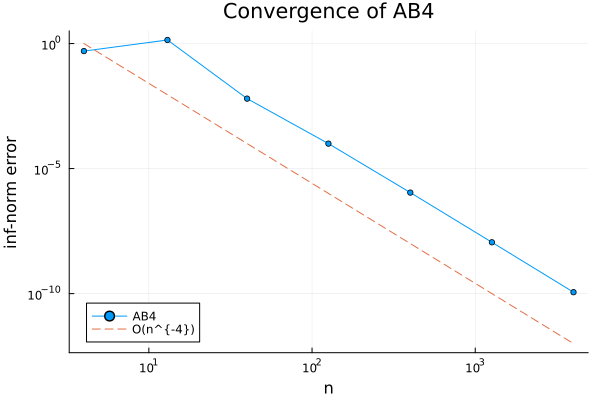

In [52]:
plot(n,errs,m=3,label="AB4",
    xaxis=(:log10,"n"),yaxis=(:log10,"inf-norm error"),
    title="Convergence of AB4",leg=:bottomleft)

plot!(n,(n/n[1]).^(-4),l=:dash,label="O(n^{-4})")

In [53]:
# | echo: false

"""
    fdjac(f,x₀[,y₀])

Compute a finite-difference approximation of the Jacobian matrix for
`f` at `x₀`, where `y₀`=`f(x₀)` may be given.
"""
function fdjac(f,x₀,y₀=f(x₀))
    δ = sqrt(eps())*max(norm(x₀),1)   # FD step size
    m,n = length(y₀),length(x₀)
    if n==1
        J = (f(x₀+δ) - y₀) / δ
    else
        J = zeros(m,n)
        x = copy(x₀)
        for j in 1:n
            x[j] += δ
            J[:,j] = (f(x) - y₀) / δ
            x[j] -= δ
        end
    end
    return J
end

fdjac

In [54]:
# | echo: false

"""
    levenberg(f,x₁[;maxiter,ftol,xtol])

Use Levenberg's quasi-Newton iteration to find a root of the system
`f` starting from `x₁`. Returns the history of root estimates 
as a vector of vectors.

The optional keyword parameters set the maximum number of iterations
and the stopping tolerance for values of `f` and changes in `x`.

"""
function levenberg(f,x₁;maxiter=40,ftol=1e-12,xtol=1e-12)
    x = [float(x₁)]
    yₖ = f(x₁)
    k = 1;  s = Inf;
    A = fdjac(f,x[k],yₖ)   # start with FD Jacobian
    jac_is_new = true

    λ = 10;
    while (norm(s) > xtol) && (norm(yₖ) > ftol)
        # Compute the proposed step.
        B = A'*A + λ*I
        z = A'*yₖ
        s = -(B\z)
        
        x̂ = x[k] + s
        ŷ = f(x̂)

        # Do we accept the result?
        if norm(ŷ) < norm(yₖ)    # accept
            λ = λ/10   # get closer to Newton
            # Broyden update of the Jacobian.
            A += (ŷ-yₖ-A*s)*(s'/(s'*s))
            jac_is_new = false
            
            push!(x,x̂)
            yₖ = ŷ
            k += 1
        else                       # don't accept
            # Get closer to gradient descent.
            λ = 4λ
            # Re-initialize the Jacobian if it's out of date.
            if !jac_is_new
                A = fdjac(f,x[k],yₖ)
                jac_is_new = true
            end
        end

        if k==maxiter
            @warn "Maximum number of iterations reached."
            break
        end
        
    end
    return x
end

levenberg

## Implicit methods

Implementing an implicit multistep method is more difficult. Consider the second-order implicit formula AM2, also known as the trapezoid method. To advance from step $i$ to $i+1$, we need to solve for $\mathbf{z}$ in the equation

$$\mathbf{z} - \tfrac{1}{2} h \mathbf{f}(t_{i+1},\mathbf{z})  = \mathbf{u}_i + \tfrac{1}{2} h \mathbf{f}(t_i,\mathbf{u}_i)$$

[This equation can be written as $\mathbf{g}(\mathbf{z})=\boldsymbol{0}$, so the rootfinding methods of Chapter 4 can be used. The new value $\mathbf{u}_{i+1}$ is equal to the root of this equation.]{.content-hidden when-format='revealjs' when-format='pptx'}  

---

In [55]:
"""
    am2(ivp,n)

Apply the Adams-Moulton 2nd order method to solve given IVP using
`n` time steps. Returns a vector of times and a vector of
solution values.
"""
function am2(ivp,n)
    # Time discretization.
    a,b = ivp.tspan
    h = (b-a)/n
    t = [ a + i*h for i in 0:n ]

    # Initialize output.
    u = fill(float(ivp.u0),n+1)

    # Time stepping.
    for i in 1:n
        # Data that does not depend on the new value.
        known = u[i] + h/2*ivp.f(u[i],ivp.p,t[i])
        # Find a root for the new value.
        g = z -> z - h/2*ivp.f(z,ivp.p,t[i+1]) - known
        unew = levenberg(g,known)
        u[i+1] = unew[end]
    end
    return t,u
end

am2

## Stiff problems

At each time step, an implicit IVP solver requires a rootfinding iteration, requiring multiple calls to evaluate the function $\mathbf{f}$. This fact makes the cost of an implicit method much greater on a per-step basis than an explicit one. 

. . .

Given this drawback, you are justified to wonder whether implicit methods are ever competitive! 

. . .

The answer is emphatically yes! 

## Example

The following simple ODE uncovers a surprise.

In [56]:
ivp = ODEProblem((u,p,t)->u^2-u^3, 0.005, (0,400.))

ODEProblem with uType Float64 and tType Float64. In-place: false
timespan: (0.0, 400.0)
u0: 0.005

---

We will solve the problem first with the implicit AM2 method using $n=200$ steps.

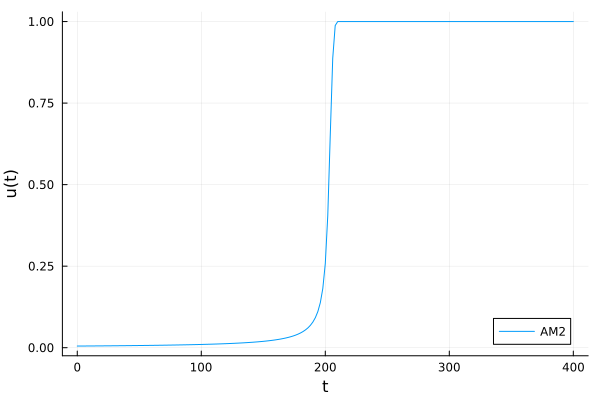

In [57]:
tI,uI = am2(ivp,200)

plot(tI,uI,label="AM2",
    xlabel="t",ylabel="u(t)",leg=:bottomright)

---

Now we repeat the process using the explicit AB4 method.

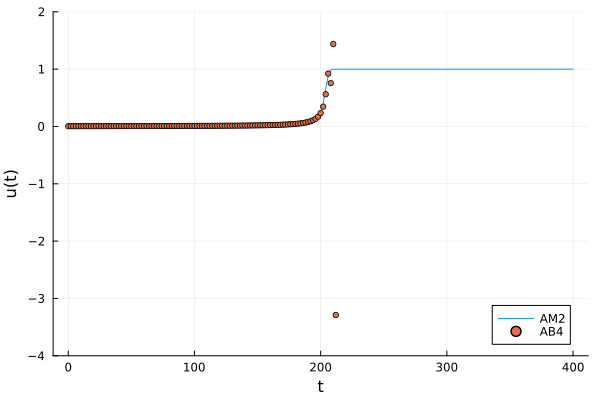

In [58]:
tE,uE = ab4(ivp,200)

scatter!(tE,uE,m=3,label="AB4",ylim=[-4,2])

. . .

Once the solution starts to take off, the AB4 result goes catastrophically wrong.

---

We hope that AB4 will converge in the limit $h\to 0$, so let's try using more steps.

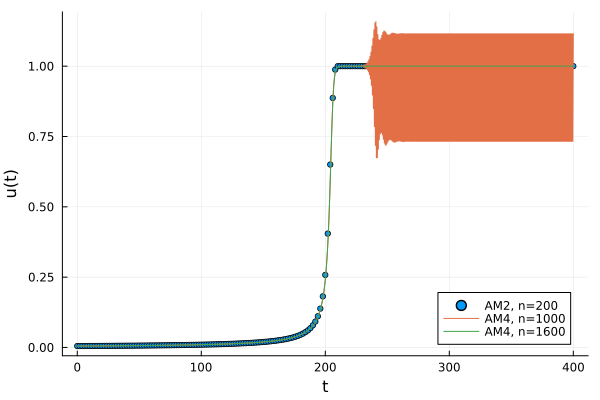

In [59]:
plt = scatter(tI,uI,label="AM2, n=200",m=3,
    xlabel="t",ylabel="u(t)",leg=:bottomright)

for n in [1000,1600]
    tE,uE = ab4(ivp,n)
    plot!(tE,uE,label="AM4, n=$n")
end
plt

. . .

So AB4, which is supposed to be _more_ accurate than AM2, actually needs something like 8 times as many steps to get a reasonable-looking answer!

---

This may seem like a contradiction to our understanding of orders of accuracy, but it is not.

. . .

A fourth-order explicit formula is more accurate than a second-order implicit one, in the limit $h\to 0$. But there is another limit to consider, $t\to \infty$ with $h$ fixed, and in this one the implicit method wins!

. . .

Problems for which implicit methods are much more efficient than explicit counterparts are called **stiff**. A sure sign of stiffness is the presence of phenomena on widely different time scales. 

[In this example, there are two slow periods during which the solution changes very little, interrupted by a very fast transition in the state. An explicit method "thinks" that the step size must always be dictated by the time scale of the fast transition, whereas an implicit method can take large steps during the slow periods.]{.content-hidden when-format='revealjs' when-format='pptx'} 

# Zero-stability of multistep methods

For one-step methods such as Runge–Kutta, it is guaranteed that the method converges and that the global error is of the same order as the local truncation error. 

. . .

For multistep methods, however, a new wrinkle is introduced.

## Example

Once can check that the two-step method LIAF, given by

$$\mathbf{u}_{i+1} = -4u_i + 5u_{i-1} + h(4f_i + 2f_{i-1}),$$

is third-order accurate.

. . .

Let's apply it to the ridiculously simple IVP $u'=u$, $u(0)=1$, whose solution is $e^t$. We'll measure the error at the time $t=1$.

In [60]:
dudt = (u,t) -> u
û = exp
a,b = 0.0,1.0;
n = [5,10,20,40,60]
errs = []
t,u = [],[]
for n in n
    h = (b-a)/n
    t = [ a + i*h for i in 0:n ]
    u = [1; û(h); zeros(n-1)]
    f = [dudt(u[1],t[1]); zeros(n)]
    for i in 2:n
        f[i] = dudt(u[i],t[i])
        u[i+1] = -4*u[i] + 5*u[i-1] + h*(4*f[i]+2*f[i-1])
    end
    push!( errs, abs(û(b) - u[end]) )
end

pretty_table( [n (b-a)./n errs], header=["n","h","error"] )

┌────┬───────────┬────────────┐
│  n │         h │      error │
├────┼───────────┼────────────┤
│  5 │       0.2 │  0.0160452 │
│ 10 │       0.1 │    2.84548 │
│ 20 │      0.05 │   1.6225e6 │
│ 40 │     0.025 │  9.3442e18 │
│ 60 │ 0.0166667 │ 1.74013e32 │
└────┴───────────┴────────────┘


---

The error starts out promisingly, but things explode from there. A graph of the last numerical attempt yields a clue.

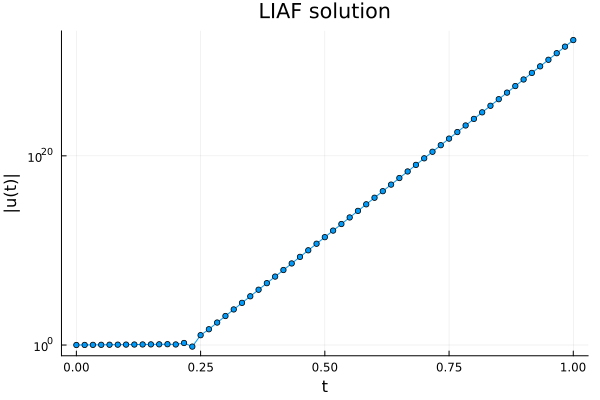

In [61]:
plot(t,abs.(u),m=3,label="",
    xlabel="t",yaxis=(:log10,"|u(t)|"),title="LIAF solution")

. . .

It's clear that the solution is growing exponentially in time.

## Zero-stability

Here is the crucial property that LIAF lacks.

::: {.callout-note icon=false}
## Definition: Zero-stability of a multistep IVP method
A multistep method is **zero-stable** if, as $h\to 0$, every numerical solution produced by the method remains bounded throughout $a\le t_i \le b$.
:::

. . .

Without zero-stability, any truncation or roundoff error will get exponentially amplified and eventually overwhelm convergence to the exact solution. 

## Dahlquist theorems

It turns out that lacking zero-stability is the only thing that can go wrong for a consistent multistep method. 

::: {.callout-warning icon=false}
## Theorem: Dahlquist equivalence
A linear multistep method converges as $h\to 0$ if and only if it is consistent and zero-stable.
:::

[The Dahlquist equivalence theorem is one of the most important and celebrated in the history of numerical analysis. It can be proved more precisely that a zero-stable, consistent method is convergent in the same sense as Euler's method, with the error between numerical and exact solutions being of the same order as the local truncation error, for a wide class of problems.]{.content-hidden when-format='revealjs' when-format='pptx'} 

## Accuracy vs Stability

You may have noticed that the Adams and BD formulas use only about half of the available data from the past $k$ steps, i.e., they have many possible coefficients set to zero. For instance, a $k$-step AB method uses only the $f_j$-values and has order $k$. 

. . .

The order could be made higher by also using $u_j$-values, like the LIAF method does for $k=2$. Also like the LIAF method, however, such attempts are doomed by instability.

::: {.callout-warning icon=false}
## Theorem: First Dahlquist stability barrier
The order of accuracy $p$ of a stable $k$-step linear multistep method satisfies

$$p \le
\begin{cases}
  k+2 & \text{if $k$ is even},\\
  k+1 & \text{if $k$ is odd},\\
  k & \text{if the method is explicit.}
\end{cases}$$

:::

. . .

The lesson of the result is that accuracy is not the only important feature, and trying to optimize for it leads to failure. 

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->